## Linear regression in finance

In [49]:
%%capture

%pip install numpy pandas matplotlib yfinance
%pip install --upgrade pip
%pip install statsmodels

In [135]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy as sp
import yfinance as yf
from scipy.stats import norm, t, ttest_1samp
from pandas.plotting import autocorrelation_plot, scatter_matrix
from statsmodels.tsa.stattools import acf

In [51]:
ticker_name = 'GOOGL'
stock_data = yf.download(ticker_name, start='2020-01-01', end='2025-12-31')
stock_data.columns = stock_data.columns.droplevel('Ticker')
stock_data = stock_data.dropna()
close_prices = stock_data['Close']

stock_data['log_returns'] = np.log(close_prices.shift(-1) / close_prices).dropna()
mean_log_return = stock_data['log_returns'].mean()
std_log_return = stock_data['log_returns'].std(ddof=1)
print(f"Mean log return = {mean_log_return}, Std log return = {std_log_return}")

[*********************100%***********************]  1 of 1 completed

Mean log return = 0.0010163165878894322, Std log return = 0.020460314543789965


In [52]:
stock_data.head()

Price,Close,High,Low,Open,Volume,log_returns
Date,,,,,,
2020-01-02,67.832512,67.832512,66.732767,66.827923,27278000,-0.005245
2020-01-03,67.477654,68.083782,66.773895,66.807600,23408000,0.026305
2020-01-06,69.276215,69.301488,66.956286,66.987503,46768000,-0.001933
2020-01-07,69.142403,69.558218,68.966465,69.407553,34330000,0.007093
2020-01-08,69.634544,69.972052,69.019499,69.128034,35314000,0.010443


### Covariance, correlation, and scatter

We now calculate the covariance matrix as well as the correlation matrix between the various columns of the data set.

In [53]:
stock_data.cov()

Price,Close,High,Low,Open,Volume,log_returns
Price,,,,,,
Close,2.459306e+03,2.483929e+03,2.431273e+03,2.458035e+03,-9.685313e+07,0.002078
High,2.483929e+03,2.510913e+03,2.456309e+03,2.484960e+03,-8.991298e+07,0.003837
Low,2.431273e+03,2.456309e+03,2.405127e+03,2.431881e+03,-1.014690e+08,0.003236
Open,2.458035e+03,2.484960e+03,2.431881e+03,2.461226e+03,-9.463660e+07,0.004586
Volume,-9.685313e+07,-8.991298e+07,-1.014690e+08,-9.463660e+07,2.216549e+14,15235.259728
log_returns,2.077653e-03,3.837053e-03,3.236042e-03,4.586457e-03,1.523526e+04,0.000419


In [54]:
stock_data.corr()

Price,Close,High,Low,Open,Volume,log_returns
Price,,,,,,
Close,1.000000,0.999579,0.999674,0.999093,-0.131180,0.002056
High,0.999579,1.000000,0.999535,0.999604,-0.120522,0.003758
Low,0.999674,0.999535,1.000000,0.999534,-0.138972,0.003239
Open,0.999093,0.999604,0.999534,1.000000,-0.128128,0.004537
Volume,-0.131180,-0.120522,-0.138972,-0.128128,1.000000,0.050018
log_returns,0.002056,0.003758,0.003239,0.004537,0.050018,1.000000


Next, we can plot these correlations using a scatter matrix.

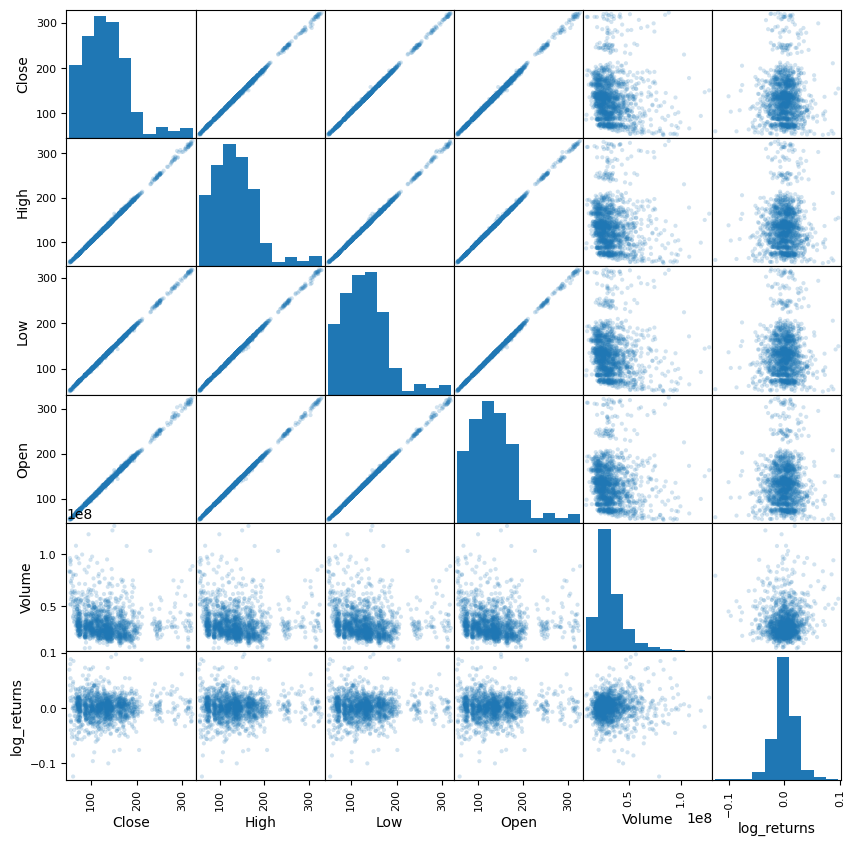

In [19]:
sm = scatter_matrix(stock_data, alpha=0.2, figsize=(10, 10), diagonal='hist')

Using a scatter plot, we observe a clear (positive) correlation between the open and close prices of the stock.

<Axes: xlabel='Open', ylabel='Close'>

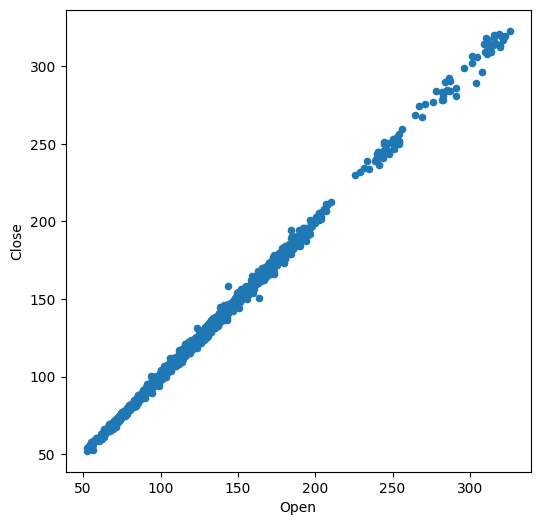

In [56]:
stock_data.plot(kind='scatter', x='Open', y='Close', figsize=(6, 6))

Similarly, we can take a closer look at the log_returns vs volume. No linear correlation is observed. 

We see a "megaphone" shape. The plot looks symmetric about log_returns = 0, meaning that trading volume cannot determine whether the stock goes up or down.

However, with increased volume, we notice a broader spread of the log_returns, indicating higher volatility.

<Axes: xlabel='Volume', ylabel='log_returns'>

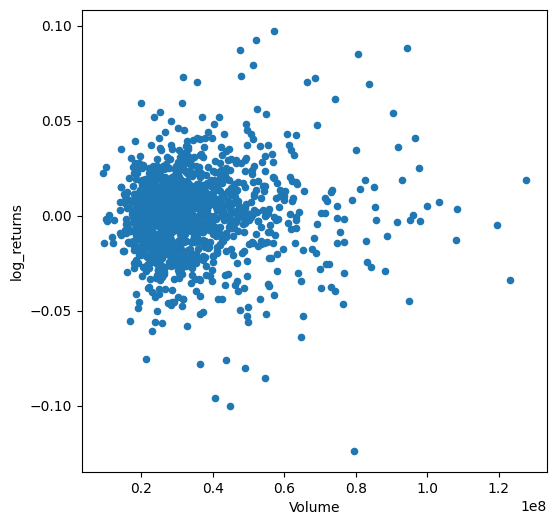

In [60]:
stock_data.plot(kind='scatter', x='Volume', y='log_returns', figsize=(6, 6))

### Autocorrelation

Now, we will explore the autocorrelation function, to see if we can identify any periodic patterns in the stock behavior. We begin by printing out autocorrelation values for various lags. 

In [62]:
for lag in range(101):
    val = stock_data['log_returns'].autocorr(lag=lag)
    print(f"Lag {lag}: {val:.6f}")

Lag 0: 1.000000
Lag 1: -0.078763
Lag 2: 0.026325
Lag 3: -0.041553
Lag 4: -0.030942
Lag 5: 0.012017
Lag 6: -0.061194
Lag 7: 0.066736
Lag 8: -0.035568
Lag 9: 0.084745
Lag 10: -0.025867
Lag 11: 0.026255
Lag 12: 0.001240
Lag 13: -0.022195
Lag 14: 0.007824
Lag 15: -0.056097
Lag 16: 0.030786
Lag 17: -0.036902
Lag 18: 0.062840
Lag 19: -0.055646
Lag 20: -0.011313
Lag 21: 0.011818
Lag 22: -0.057526
Lag 23: 0.001804
Lag 24: 0.007024
Lag 25: 0.034301
Lag 26: -0.024805
Lag 27: 0.004145
Lag 28: 0.024425
Lag 29: 0.019653
Lag 30: -0.029907
Lag 31: 0.035241
Lag 32: 0.031108
Lag 33: -0.058055
Lag 34: -0.001403
Lag 35: 0.060082
Lag 36: -0.004816
Lag 37: 0.003433
Lag 38: -0.000718
Lag 39: -0.025307
Lag 40: 0.003326
Lag 41: -0.025547
Lag 42: 0.049114
Lag 43: 0.006091
Lag 44: -0.016514
Lag 45: 0.036431
Lag 46: -0.023340
Lag 47: 0.032254
Lag 48: -0.034320
Lag 49: -0.019972
Lag 50: 0.014674
Lag 51: -0.019624
Lag 52: 0.028560
Lag 53: 0.038059
Lag 54: -0.005071
Lag 55: 0.003028
Lag 56: 0.005555
Lag 57: -0.0301

We can also plot these autocorrelation values against the lag. 

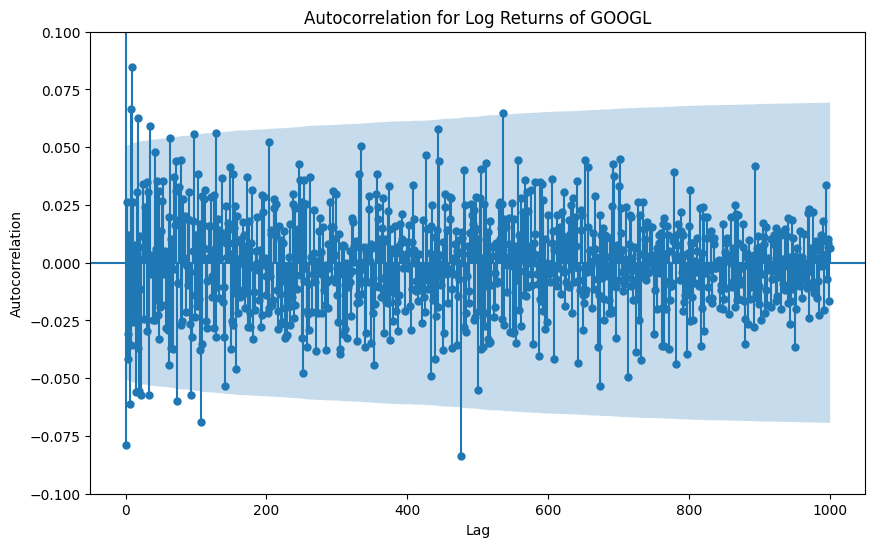

In [69]:
n_lag = 1000
fig, ax = plt.subplots(figsize=(10, 6))
plot_acf(stock_data['log_returns'].dropna(), lags=n_lag, ax=ax)

plt.title(f"Autocorrelation for Log Returns of {ticker_name}")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.ylim(-0.1, 0.1)
plt.show()

Conclusions:

- The vertical spikes bounce randomly above and below the zero line. The vast majority of the lags stay locked inside the shaded blue region (95% confidence interval, calculated using Bartlett's formula for the variance of a discrete time series). This confirms that past returns hold no statistical power for predicting future directional moves.
- Significant short-term memory (Lag 1 & 2): At the far left, Lag 1 breaks significantly below the blue confidence band at roughly -0.079, followed immediately by a positive bounce at Lag 2. This indicates short-term mean reversion or "market noise matching". A strong move one day frequently sees a minor technical correction the next. 
- Isolated random spikes: A small fraction of the individual spikes poke outside the shaded blue cone. Because we are testing 1000 lags at a 95% confidence level, pure mathematical chance dictates that roughly 5% of the points (about 50 spikes) will look significant even when the data is entirely random. These are false positives, not real trading signals.

## Linear regression


In [70]:
import statsmodels.formula.api as smf

We will create a noisy version of a straight line, and then use the OLS function to fit a straight line through the data points.

The model is $y = b_0 + b_1 x$, and we account for random fluctuations by including a Gaussian noise term: $y= b_0 + b_1 x + \varepsilon$. Here, $\varepsilon \sim N(0,\sigma^2)$.

### Theoretical solution

Given a set of data points $\{(x_i,y_i)\}_{i=1}^n$, we can minimize the least square error to find:
$$b_1 = \frac{\sum_{i=1}^n (y_i - \bar{y})(x_i - \bar{x})}{\sum_{i=1}^n (x_i - \bar{x})^2} , \quad b_0 = \bar{y} - b_1 \bar{x}.$$


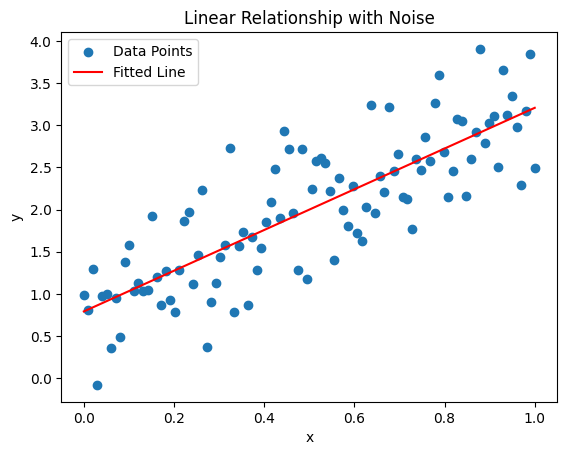

In [83]:
noise = np.random.normal(0, 0.5, 100)
x = np.linspace(0, 1, 100)
y = 2 * x + 1 + noise

model = smf.ols('y ~ x', data=pd.DataFrame({'x': x, 'y': y})).fit()

plt.scatter(x, y, label='Data Points')
plt.plot(x, model.predict(pd.DataFrame({'x': x})), color='red', label='Fitted Line')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Linear Relationship with Noise')
plt.legend()
plt.show()

In [102]:
print(model.summary())

print(f"Estimated Intercept: {model.params.iloc[0]:.3f}")
print(f"Estimated Slope for x: {model.params.iloc[1]:.3f}")
print(f"R-squared value: {model.rsquared:.3f}")

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.674
Model:                            OLS   Adj. R-squared:                  0.671
Method:                 Least Squares   F-statistic:                     202.7
Date:                Wed, 29 Jul 2026   Prob (F-statistic):           1.35e-25
Time:                        12:31:01   Log-Likelihood:                -70.452
No. Observations:                 100   AIC:                             144.9
Df Residuals:                      98   BIC:                             150.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.7915      0.098      8.064      0.0

In [113]:
b_0 = model.params.iloc[0]
b_1 = model.params.iloc[1]
n = len(x)
y_fit = b_0 + b_1 * x

r_square = 1 - (np.sum((y - y_fit) ** 2) / np.sum((y - np.mean(y)) ** 2))
print(f"R-squared value (manual calculation): {r_square:.3f}")

R-squared value (manual calculation): 0.674


### Significance of input variable

We can also run a hypothesis test to see the significance of the input $x$ on the output $y$. For this, the null hypothesis is that $b_1= 0$, while the alternative hypothesis is that $b_1 \neq 0$. If this is the case, then $y$ is independent of $x$.

Under this hypothesis, we can calculate $\hat{t} = \frac{b_1 - 0}{s}$, and then evaluate the probability $p = P(t>|\hat{t}|)$.

#### Calculating the standard error of the coefficient $b_1$

We know that 
$$b_1 = \frac{\sum_{i=1}^n (y_i - \bar{y})(x_i - \bar{x})}{\sum_{i=1}^n (x_i - \bar{x})^2} = \frac{\sum_{i=1}^n y_i(x_i - \bar{x})}{\sum_{i=1}^n (x_i - \bar{x})^2},$$
where we used $\sum_{i} \bar{y}(x_i - \bar{x}) = 0$.

Now, the input values $x_i$ are fixed, and the effect of the random fluctuations is only on the output values $y_i$. So, we can use the properties of the variance to write:
$$\text{Var}(b_1) = \frac{\sum_{i=1}^n (x_i - \bar{x})^2 \sigma^2}{(\sum_{i=1}^n (x_i - \bar{x})^2)^2} = \frac{\sigma^2}{\sum_{i=1}^n (x_i - \bar{x})^2} ,$$
where $\sigma^2 = \text{Var}(\varepsilon) = \text{Var}(y_i)$.

In practice, we don't know $\sigma^2$ a priori. So, we calculate it as the sample variance of $y_i - y_{\text{fit}}$, except that we must use 2 degrees of freedom, since $\bar{x}$ and $\bar{y}$ are already fixed in the estimation of the parameters of the linear fit. Thus, 
$$\text{Sample Var}(b_1) = \frac{\left(\frac{\sum_{i=1}^n (y_i - \bar{y})^2}{n-2}\right)}{\sum_{i=1}^n (x_i - \bar{x})^2}.$$
The standard error is the square root of this sample variance.

In [ ]:
xbar = np.mean(x)
resy = np.sum((y - y_fit) ** 2)
resx = np.sum((x - xbar) ** 2)
s = np.sqrt((resy/(n-2))/resx)

t_stat = np.abs(b_1) / s
confidence = 0.95
alpha = 1 - confidence
p = 2*t.sf(t_stat, df=n-2)

print(f"t-statistic = {t_stat:.5f}, p-value = {p:.5e}")
if p < alpha:
    print(f"Reject the null hypothesis. (Independent variable has a significant effect.)")
else:
    print(f"Fail to reject the null hypothesis. (Independent variable does not have a significant effect.)")

t-statistic = 14.23688, p-value = 1.35248e-25
Reject the null hypothesis. (Independent variable has a significant effect.)


Finally, we can also determine the confidence interval for the slope $b_1$. We shall continue to use the confidence level of 95%.

In [111]:
confidence = 0.95
alpha = 1-(1-confidence)/2
t_crit = t.ppf(alpha, df=n-2)
ci_lower = b_1 - t_crit * s
ci_upper = b_1 + t_crit * s
print(f"95% Confidence Interval for the slope: ({ci_lower:.5f}, {ci_upper:.5f})")

95% Confidence Interval for the slope: (2.07772, 2.75076)


A similar analysis can also be done for the intercept parameter $b_0$. We begin from 
$$b_0 = \bar{y} - b_1 \bar{x} = \frac{1}{n} \sum_{i} y_i - \bar{x} \sum_i w_i y_i = \sum_i \left(\frac{1}{n} - \bar{x} w_i \right) y_i,$$
where $w_i = \frac{x_i - \bar{x}}{\sum_k (x_k - \bar{x})^2}$. Then, we can derive the required expression for the variance of $b_0$, i.e.,
$$\text{Var}(b_0) = \sigma^2\left(\frac{1}{n} + \frac{\bar{x}^2}{\sum_k (x_k - \bar{x})^2}\right).$$

Once again, we can estimate $\sigma^2$ using the sample variance of $y_i - y_{\text{fit}}$, with $n-2$ degrees of freedom.

### Testing for linearity, independence, normality, and equal variance of our data

#### Linearity
This aspect is clear from plotting the data.

#### Independence
First, we plot the "time series" of the errors: $e_i = y_i - y_{\text{fit}}(i)$.

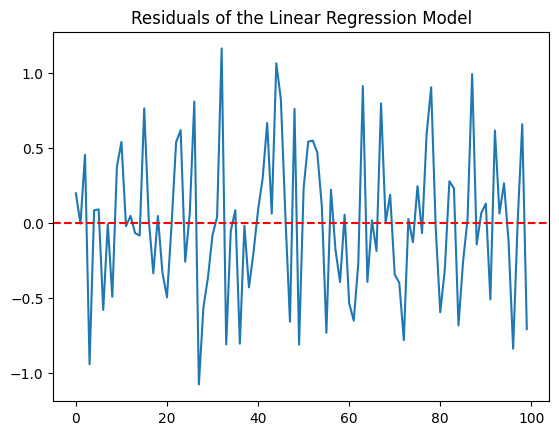

In [117]:
e = y - y_fit
plt.plot(e)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals of the Linear Regression Model')
plt.show()

It appears that there is no correlation between the various errors. How can we confirm this quantitatively? We use the Durbin-Watson statistic:
$$d = \frac{\sum_i (e_i - e_{i-1})^2}{\sum_i e_i^2}.$$

The value of $d$ is approximately $2(1-\hat{\rho})$, where $\hat{\rho}$ is the sample autocorrelation at lag 1. Therefore, $0\le d \le 4$. A value close to 2 indicates no autocorrelation, while a value less (more) than 2 indicates positive (negative) correlation.

In [119]:

d = np.sum((e[1:] - e[:-1]) ** 2) / np.sum(e ** 2)
print(f"Durbin-Watson statistic: {d:.5f}")

Durbin-Watson statistic: 2.04759


Since it is very close to 2, we conclude no autocorrelation. Hence, the errors are independent.

#### Normality

We can make a QQ-plot, to compare the quantiles of the errors against the quantiles of a standard normal distribution (shown in red). Since our noise was sampled from a normal distribution anyway, the excellent agreement should not come as a surprise.

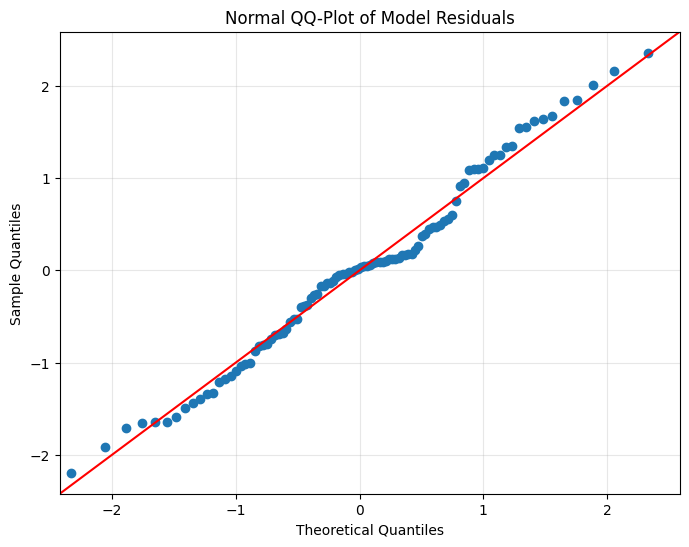

In [139]:
from statsmodels.graphics.gofplots import qqplot
fig, ax = plt.subplots(figsize=(8, 6))
z = (e - np.mean(e)) / np.std(e, ddof=1)
qqplot(z, dist=sp.stats.norm, line="45", ax=ax)
plt.title("Normal QQ-Plot of Model Residuals")
plt.grid(True, alpha=0.3)
plt.show()

#### Equal variance

Finally, a linear regression model is applicable when the variance of the error is independent of the predictors. This can be observed from the following plot.

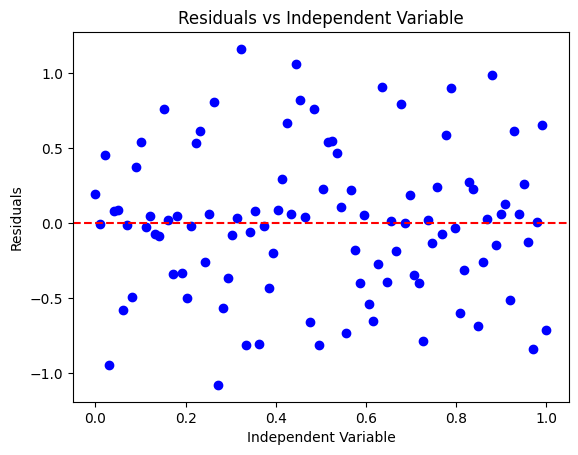

In [140]:
plt.scatter(x, e, color='blue')
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals vs Independent Variable')
plt.xlabel('Independent Variable')
plt.ylabel('Residuals')
plt.show()